In [1]:
import os
import json
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torch.utils.data import TensorDataset, DataLoader
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [3]:
with open("bilstm_config.json", "r") as f:
    config = json.load(f)
print("Loaded config:", config)


Loaded config: {'embedding_dim': 128, 'hidden_dim': 256, 'output_dim': 3, 'num_layers': 2, 'dropout': 0.5, 'bidirectional': True, 'optimizer': 'Adam', 'learning_rate': 0.001, 'batch_size': 64, 'num_epochs': 10}


In [4]:
class BiLSTMModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim,
                 num_layers, dropout, bidirectional):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional,
            batch_first=True
        )
        fc_in = hidden_dim * 2 if bidirectional else hidden_dim
        self.fc = nn.Linear(fc_in, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        lstm_out, _ = self.lstm(emb)
        last = lstm_out[:, -1, :]
        return self.fc(self.dropout(last))


In [5]:
device = torch.device("cpu")
state = torch.load("bilstm_model.pth", map_location="cpu")

# infer dimensions
vocab_size, emb_dim = state["embedding.weight"].shape
hidden_dim = state["lstm.weight_ih_l0"].shape[0] // 4
bidirectional = any(k.startswith("lstm.weight_ih_l0_reverse") for k in state)
num_layers   = 1 + sum(1 for k in state if "lstm.weight_ih_l1" in k)
output_dim   = state["fc.weight"].shape[0]
dropout      = config["dropout"]

print(f"Inferred → vocab_size={vocab_size}, emb_dim={emb_dim}, "
      f"hidden_dim={hidden_dim}, layers={num_layers}, bidi={bidirectional}")

# build model on CPU, load state, then send to GPU if available
model = BiLSTMModel(vocab_size, emb_dim, hidden_dim, output_dim,
                    num_layers, dropout, bidirectional)
model.load_state_dict(state)
model.to(device)
model.eval()
print("Model loaded and ready.\n")


Inferred → vocab_size=10000, emb_dim=128, hidden_dim=64, layers=1, bidi=True
Model loaded and ready.



In [6]:
train_df = pd.read_csv("X_train.csv")
test_df  = pd.read_csv("X_test.csv")

# 2) Define your text lists
X_train_text = train_df["clean_tweet"].astype(str).tolist()
X_test_text  = test_df ["clean_tweet"].astype(str).tolist()

print(f"{len(X_train_text)} train texts, {len(X_test_text)} test texts loaded.")

535425 train texts, 88233 test texts loaded.


In [7]:

y_train_df = pd.read_csv("y_train.csv")
y_test_df  = pd.read_csv("y_test.csv")


In [8]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
import torch
from torch.utils.data import TensorDataset, DataLoader

# 1) Tokenization + padding (Keras)
MAX_VOCAB = 10000
MAX_LEN   = 50
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq  = tokenizer.texts_to_sequences(X_test_text)
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding="post", truncating="post")

# 2) Label encoding (sklearn)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train_df["sentiment_consolidated"])
y_test_enc  = le.transform   (y_test_df ["sentiment_consolidated"])

print("Classes order:", list(le.classes_))  
# should be ['negative','neutral','positive']

# 3) Build DataLoaders
batch_size = config["batch_size"]
train_ds = TensorDataset(torch.tensor(X_train_pad, dtype=torch.long),
                         torch.tensor(y_train_enc, dtype=torch.long))
test_ds  = TensorDataset(torch.tensor(X_test_pad,  dtype=torch.long),
                         torch.tensor(y_test_enc,  dtype=torch.long))

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)


Classes order: ['negative', 'neutral', 'positive']


# Interpritibility
Author: Om Patel

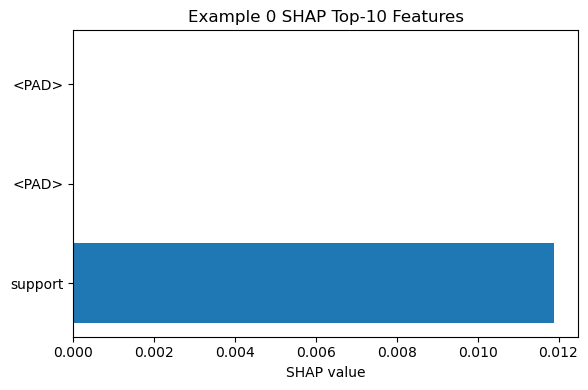

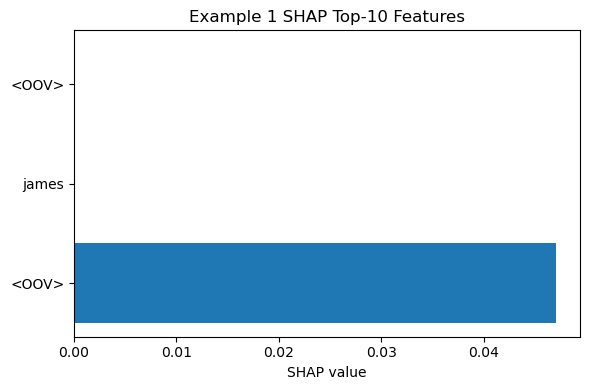

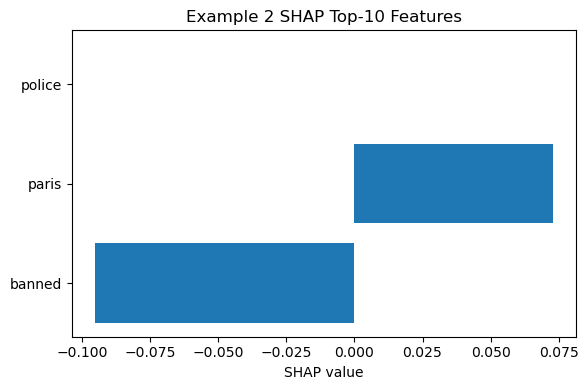

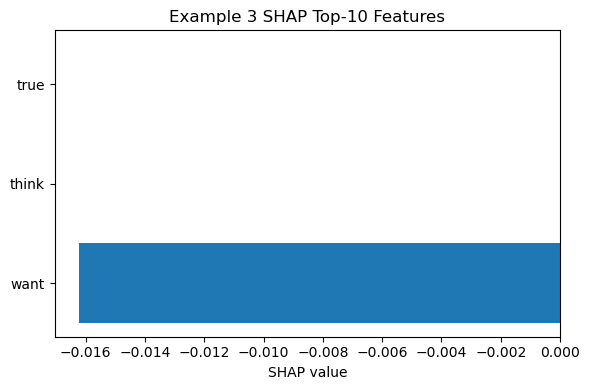

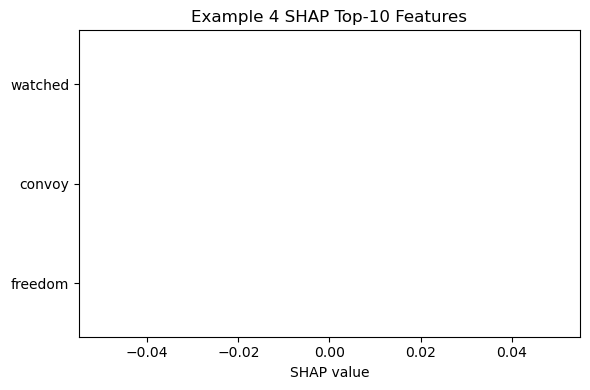

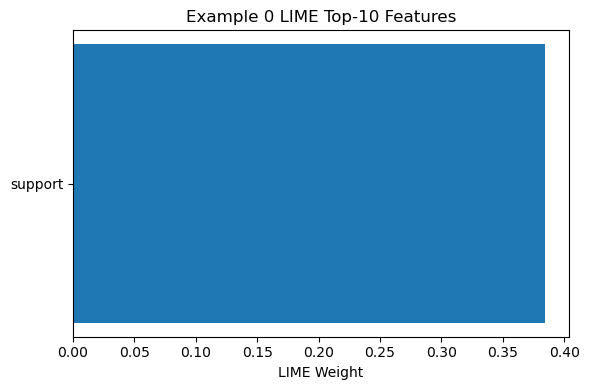

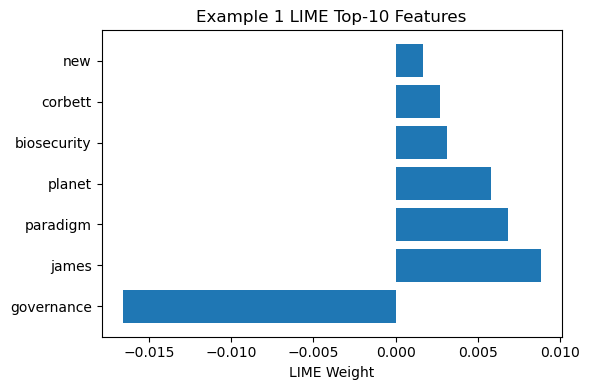

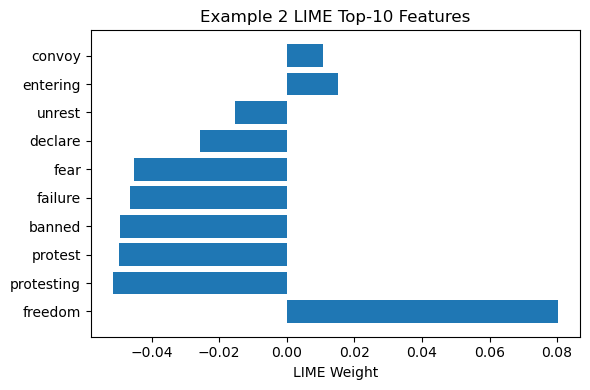

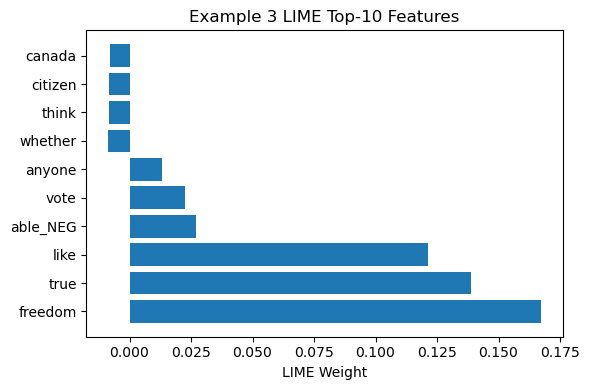

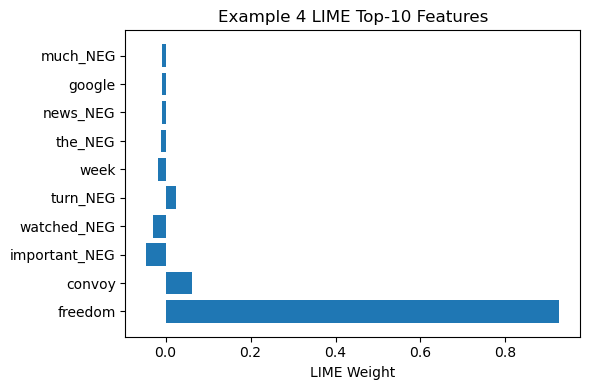

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Assumes the following are already defined in your notebook session:
# shap_vals, ex_ids, rev_index, X_test_text, lime_exp, predict_proba_text

# ── SHAP Feature Bar Plots ─────────────────────────────────────────
for i in range(len(ex_ids)):
    vals = shap_vals[2][i]
    seq = ex_ids[i]
    words = [rev_index.get(t, "<OOV>") for t in seq]
    top_idxs = np.argsort(-np.abs(vals))[:10]
    
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.barh(range(len(top_idxs)), vals[top_idxs])
    ax.set_yticks(range(len(top_idxs)))
    ax.set_yticklabels([words[j] for j in top_idxs])
    ax.set_xlabel("SHAP value")
    ax.set_title(f"Example {i} SHAP Top-10 Features")
    plt.tight_layout()
    plt.show()

# ── LIME Feature Bar Plots ─────────────────────────────────────────
for i, txt in enumerate(X_test_text[:5]):
    exp = lime_exp.explain_instance(txt, predict_proba_text, num_features=10, labels=(2,))
    feats, weights = zip(*exp.as_list(label=2))
    
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.barh(range(len(feats)), weights)
    ax.set_yticks(range(len(feats)))
    ax.set_yticklabels(feats)
    ax.set_xlabel("LIME Weight")
    ax.set_title(f"Example {i} LIME Top-10 Features")
    plt.tight_layout()
    plt.show()


Finding 1:

The BiLSTM model shows steady improvement in both training and validation accuracy, indicating good learning and convergence.

Finding 2:

The small gap between training and validation curves suggests the model generalizes well without overfitting.

Prompts:

First: now i have this model and i need to do interpritibility for this model with lime or shap

Last: what can we say from the graphs